# Prosjekt 3
##### Lukas Skjevik & Einar Aarnæs

### Oppgave 1

##### Oppgave 1a)

Vi ønsker å løse likningen $\frac{d^2y}{dy^2} = -4sin(2x), \quad y(0) = 0, \quad y'(0) = 2$.

Ved å antiderivere begge sider mhp. x får vi:

$y(x) = sin(2x) + Bx + C, \quad B, C \in \mathbb{R}$.

Innsatt initialverdibetingelser:

$y'(0) = 2 \implies 2cos(2 \cdot 0) + B = 2 \implies B = 0$

$y(0) = 0 \implies sin(2 \cdot 0) + C = 0 \implies C = 0$

Som gir den endelige løsningen:

$y(x) = sin(2x)$

##### Oppgave 1b)

Vi vil skrive om systemet til et 1. ordens system for vektoren $\vec{y}(x) = \begin{pmatrix} y(x) \\ y'(x) \end{pmatrix}$.

Kan umiddelbart skrive ned at initialbetingelsen er $\vec{y}(0) = \begin{pmatrix} 0 \\ 2 \end{pmatrix}$.

Matrisen vår er lettest å finne ved å la $y(x) = u_1$ og $y'(x) = u_2$. Det gir at $u_1' = u_2$ og $u_2' = -4sin(2x)$. Dette gir likningen

$\vec{y}'(x) = \begin{bmatrix}
    0 & 1 \\
    0 & 0
\end{bmatrix} \vec{y}(x) + \begin{bmatrix}
    0 \\
    -4sin(2x)
\end{bmatrix}
$

##### Oppgave 1c)

In [6]:
import numpy as np
from matplotlib import pyplot as plt

In [12]:


def rk_32(x_init, x_end, y_init, f, h0, tol = 1e-7, alpha = 0.8):
    """
    
    Args:
        x_init (float): 
        x_end (float): 
        y_init (np array):
        f (function): 
        h0 (float):
        tol (float, optional)
        alpha(float, optional)

    Returns:
        x_vals (np array):
        y_vals (np array):
        h_vals (np array):

    """
    x = x_init
    y = y_init
    h = h0
    n = 0
    k_1 = f(x, y)

    x_vals = [x]
    y_vals = [y]
    h_vals = []

    while x_end - x > 0:

        h = min(h, x_end - x)

        k_2 = f(x + 0.5*h, y + 0.5*h*k_1)
        k_3 = f(x + 0.75*h, y + 0.75*h*k_2)

        y_next = y + 1/9*h*(2*k_1+3*k_2+4*k_3)
        x_next = x + h

        k_4 = f(x_next, y_next)

        z_next = y + 1/24*h*(7*k_1+6*k_2+8*k_3+3*k_4)

        est = np.linalg.norm(y_next - z_next)

        if est < tol: #Accept step
            n += 1
            k_1 = k_4
            x_vals.append(x)
            y_vals.append(y)
            h_vals.append(h)
            x = x_next
            y = y_next

        #Updating h
        h = alpha*h*(tol/est)**(1/3)
    
    return np.array(x_vals), np.array(y_vals), np.array(h_vals)


def func_1c(x, y):
    return np.array([y[1], -4*np.sin(2*x)])


C:\Users\Einar\AppData\Local\Temp\ipykernel_18340\2903739899.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


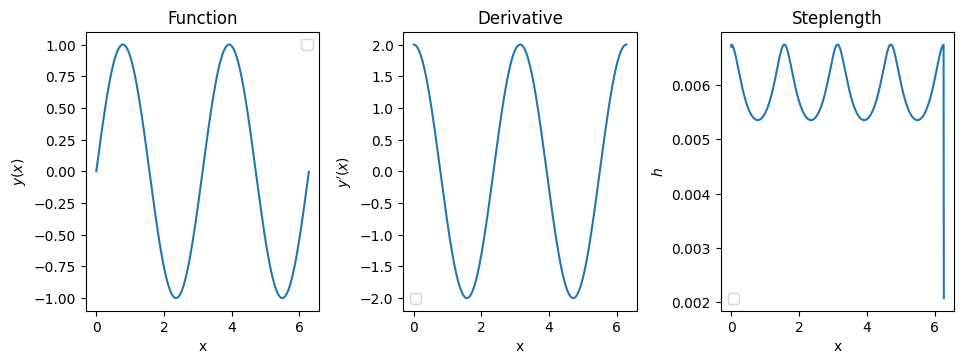

In [23]:
x_vals, y_vals, h_vals = rk_32(0, 2*np.pi, np.array([0,2]), func_1c, 0.1)

fig, axs = plt.subplots(ncols = 3, nrows = 1, figsize=(10,4))

axs[0].plot(x_vals, y_vals[:,0])
axs[0].set_ylabel("$y(x)$")
axs[0].set_title("Function")

axs[1].plot(x_vals, y_vals[:,1])
axs[1].set_ylabel("$y'(x)$")
axs[1].set_title("Derivative")

axs[2].plot(x_vals[:-1], h_vals)
axs[2].set_ylabel("$h$")
axs[2].set_title("Steplength")


for ax in axs:
    ax.set_xlabel("x")
    ax.legend()

plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=1.0)

Forklaring på variasjonen i steglengde:

Vi ser at vi har lav steglengde ved ekstremalpunktene, og høyere steglengde imellom. Dette kommer av at i området mellom ekstremalpunktene ser funksjonen mer eller mindre lineær ut, som vil si at den deriverte ikke endrer seg i særlig grad. Det vil si at vi får mindre feil om vi tar et stort seg ved hjelp av den deriverte. Rundt ekstremalpunktene endrer den deriverte seg mye, slik at feilen blir stor om vi tar lange steg. Derfor må steglengden reduseres. Irregulariteten på slutten av grafen for steglengde kan forklares med at nest siste steg tilfeldigvis tok oss veldig nær x_end, slik at det siste steget blir lite av den grunn.

##### Oppgave 1d)

In [ ]:
def solution_1b(x):
    return np.sin(2*x)

